Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Projections in Python

One of the biggest issues in GIS is comparing data in different projections. Because Python objects don't have an internal understanding of coordinate systems there is no "on-the-fly" reprojection as you would expect with a desktop GIS package like QGIS. Instead in Python when you are working with data in different projections you will have to reproject it manually.

## Projections with `pyproj`

The Python `pyproj` library is a wrapper around the common [proj4 (https://trac.osgeo.org/proj/wiki/ProjAPI)](https://trac.osgeo.org/proj/wiki/ProjAPI) toolkit for projection data in different coordinate systems. It allows you to take coordinate pairs of vectors of coordinates and transform them between any two projections (including custom projections).

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import shapely.geometry # we will use this to quickly define a geometry
import matplotlib.pyplot as plt
import cartopy # used with matplotlib to draw spatial data

import pyproj

In [3]:
point = np.array([144.963, -37.814]) # A point in GDA94 projection
poly = np.array(shapely.geometry.Point(point).buffer(1).exterior)

First we'll take a look at the data we want to project in its native projection using cartopy. (*Note* cartopy has its own system for defining projections - we discuss this elsewhere.)

In [4]:
def coords_to_polygon(coords):
    return shapely.geometry.Polygon(shapely.geometry.LinearRing(coords))

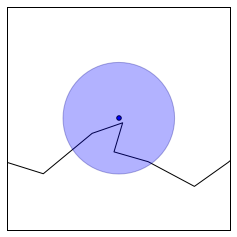

In [5]:
geodetic = cartopy.crs.PlateCarree()
ax = plt.axes(projection=geodetic)
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(
    cartopy.feature.ShapelyFeature([coords_to_polygon(poly), ], geodetic),
    edgecolor='darkblue', facecolor='blue', alpha=0.3)
ax.scatter(point[0], point[1], transform=geodetic)
ax.set_extent((point[0] - 2, point[0] + 2, point[1] - 2, point[1] + 2), geodetic)

The first step to projecting data with `pyproj` is to define a projection object. The `pyproj.Proj` class takes proj4 parameters as a single string or as keyword arguments. Fortunately this includes the `init` parameter so you can define a projection using EPSG codes (see <http://spatialreference.org> for a searchable database of EPSG codes).

In [6]:
gda94 = pyproj.Proj(init="epsg:4283")
mga_z55 = pyproj.Proj("+proj=utm +zone=55 +south +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs") #epsg:28355

Then to do the projection it is a matter of calling the `transform` function, defining a "from" projection, a "to" projection and then either a single x and a single y coordinate

In [7]:
mga_point = pyproj.transform(gda94, mga_z55, point[0], point[1])

or an array of x coordinates and an array of y coordinates.

In [8]:
mga_poly = np.column_stack(pyproj.transform(gda94, mga_z55, poly[:, 0], poly[:, 1]))

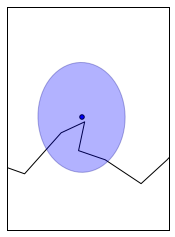

In [9]:
utm = cartopy.crs.epsg(28355)
ax = plt.axes(projection=utm)
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(
    cartopy.feature.ShapelyFeature([coords_to_polygon(mga_poly), ], utm),
    edgecolor='darkblue', facecolor='blue', alpha=0.3)
ax.scatter(mga_point[0], mga_point[1], transform=utm)
ax.set_extent((point[0] - 2, point[0] + 2, point[1] - 2, point[1] + 2), geodetic) #leave the bounds the same

## Projecting raster data in Rasterio

**Note** Unless there is no choice this is not the best approach. If raster projection needs to be done at all it should be done using the [`gdalwarp` command line utility (http://gdal.org/gdalwarp.html)](http://gdal.org/gdalwarp.html).

`Rasterio` provides an interface for projecting raster data in `rasterio.warp`.

In [10]:
import rasterio
import rasterio.warp
from affine import Affine

First you need some raster data to reproject.

In [11]:
src = rasterio.open("/Data/spatial/elevation.tif")
data = src.read(1)

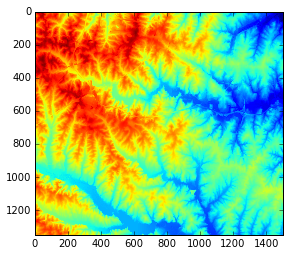

In [12]:
plt.imshow(data)

Then, having decided on a destination projection, you need to manually calculate the new geotransform, which has the form:

In [ ]:
(top_left_x, x_cell_size, x_rotation, top_left_y, y_rotation, y_cell_size)

You can do this with the help of `pyproj`:

In [13]:
wgs84 = pyproj.Proj(init="epsg:4326")
src_proj = pyproj.Proj(**src.crs)

In [14]:
top_left_x, top_left_y = pyproj.transform(src_proj, wgs84, src.bounds.left, src.bounds.top)
top_left_x, top_left_y

(-78.77428134466787, 35.80960938344993)

You also need the cellsize, so you need to get the coordinates for the opposite corner of the array as well:

In [15]:
bottom_right_x, bottom_right_y = pyproj.transform(src_proj, wgs84, src.bounds.right, src.bounds.bottom)

In [16]:
x_cell_size = (bottom_right_x - top_left_x) / src.width
y_cell_size = (bottom_right_y - top_left_y) / src.height

In [17]:
new_transform = Affine.from_gdal(top_left_x, x_cell_size, 0., top_left_y, 0., y_cell_size)

You need a numpy array to write into:

In [18]:
out_data = np.zeros((src.height, src.width))

In [19]:
out_data.shape == data.shape

True

Finally we can perform the actual reprojection:

In [20]:
rasterio.warp.reproject(
    data,
    out_data,
    src_transform=src.affine,
    src_crs=src.crs,
    dst_transform=new_transform,
    dst_crs={'init': 'EPSG:4326'},
    resampling=rasterio.warp.RESAMPLING.nearest)

and look at the results:

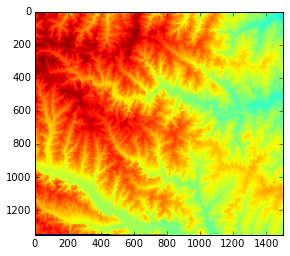

In [21]:
plt.imshow(out_data)